In [1]:
import pandas as pd
import os
import numpy as np

In [2]:
path = "https://raw.githubusercontent.com/ivandn14/IS477-Maestros/main/IS477Project"
dfint = pd.read_csv(path + "/Real%20Interest%20Rate%20Dataset.csv")

In [3]:
dfint.head()

,Data Source,World Development Indicators,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Last Updated Date,4/8/2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Country Name,Country Code,Indicator Name,Indicator Code,1960.0,1961.0,1962.0,1963.0,1964.0,1965.0,...,2016.00000,2017.00000,2018.000000,2019.00000,2020.000000,2021.000000,2022.000000,2023.000000,2024.0,2025.0
4,Aruba,ABW,Real interest rate (%),FR.INR.RINR,NaN,NaN,NaN,NaN,NaN,NaN,...,7.46758,6.14328,3.268734,4.74305,10.059563,4.722201,1.736462,-1.222154,NaN,NaN


In [4]:
dfint = dfint.drop(index=[0, 1, 2])
dfint.columns = dfint.iloc[0]
dfint = dfint[1:]
dfint = dfint.reset_index(drop=True)
dfint.columns = [
    str(int(col)) if isinstance(col, float) and col.is_integer() else str(col)
    for col in dfint.columns]
dfint = dfint.fillna(0)
dfint = dfint.drop(dfint.columns[[1,2,3, -1]], axis=1)
dfint.to_csv("cleaned_file.csv", index=False)
dfint.head(5)

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.426358,7.467580,6.143280,3.268734,4.743050,10.059563,4.722201,1.736462,-1.222154,0.000000
1,Africa Eastern and Southern,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,12.252548,17.583938,12.141178,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,Africa Western and Central,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Angola,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,20.443802,-4.212861,-6.391178,-3.608117,-0.475966,3.095126,-11.979429,1.689307,-0.855065,-4.177558


In [5]:
group_indices = dfint.index[dfint["Country Name"].str.contains(
    "Africa|income|World|Euro|Union|states|Asia|Europe|Caribbean|Pacific|OECD|demographic|IBRD|IDA",
    case=False,
    na=False
)]

print(group_indices.tolist())

[1, 3, 7, 34, 36, 49, 61, 62, 63, 64, 65, 68, 73, 95, 102, 103, 104, 105, 107, 128, 134, 136, 139, 140, 142, 153, 156, 161, 181, 183, 191, 197, 198, 204, 215, 217, 218, 230, 231, 236, 238, 240, 241, 242, 249, 251, 259, 263]


In [6]:
dfint = dfint.drop(index=[1, 3, 7, 34, 36, 49, 61, 62, 63, 64, 65, 68, 73, 95, 102, 103, 104, 105, 107, 128, 134, 136, 139, 140, 142, 153, 156, 161, 181, 183, 191, 197, 198, 204, 215, 217, 218, 230, 231, 236, 238, 240, 241, 242, 249, 251, 259, 263])
dfint.to_csv("cleaned_file.csv", index=False)
dfint = dfint.reset_index(drop=True)
dfint.head(5)

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.426358,7.467580,6.143280,3.268734,4.743050,10.059563,4.722201,1.736462,-1.222154,0.000000
1,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,12.252548,17.583938,12.141178,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Angola,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,20.443802,-4.212861,-6.391178,-3.608117,-0.475966,3.095126,-11.979429,1.689307,-0.855065,-4.177558
3,Albania,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.051516,7.664675,3.402218,4.415049,5.222938,6.077273,2.491593,-3.053790,0.584259,3.996117
4,Andorra,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [7]:
dfgdp = pd.read_csv(path + "/Real%20GDP%20Dataset.csv")
dfgdp = dfgdp.drop(index=[0, 1, 2])
dfgdp.columns = dfgdp.iloc[0]
dfgdp = dfgdp[1:]
dfgdp = dfgdp.reset_index(drop=True)
dfgdp.columns = [
    str(int(col)) if isinstance(col, float) and col.is_integer() else str(col)
    for col in dfgdp.columns]
dfgdp = dfgdp.fillna(0)
dfgdp = dfgdp.drop(dfgdp.columns[[1,2,3, -1]], axis=1)
dfgdp.to_csv("cleaned_file.csv", index=False)
dfgdp.head(5)

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.962907e+09,2.983637e+09,3.092428e+09,3.276188e+09,3.346623e+09,2.471419e+09,2.880903e+09,3.324034e+09,3.834730e+09,4.265651e+09
1,Africa Eastern and Southern,2.420569e+10,2.495889e+10,2.707323e+10,3.176914e+10,3.027955e+10,3.380618e+10,3.692725e+10,3.844416e+10,4.174200e+10,...,9.100020e+11,8.318680e+11,9.780760e+11,1.020960e+12,1.018710e+12,9.386080e+11,1.114140e+12,1.228970e+12,1.179360e+12,1.242690e+12
2,Afghanistan,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,1.913422e+10,1.811657e+10,1.875346e+10,1.805322e+10,1.879944e+10,1.995593e+10,1.426000e+10,1.449724e+10,1.715223e+10,0.000000e+00
3,Africa Western and Central,1.190481e+10,1.270772e+10,1.363059e+10,1.446891e+10,1.580356e+10,1.692088e+10,1.803395e+10,1.649354e+10,1.702260e+10,...,7.780220e+11,7.000280e+11,6.940510e+11,7.778400e+11,1.027000e+12,9.637850e+11,1.026650e+12,1.063650e+12,9.382380e+11,7.363850e+11
4,Angola,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,1.025430e+11,5.987825e+10,8.437694e+10,8.951279e+10,8.073443e+10,5.885246e+10,7.955954e+10,1.312120e+11,1.071680e+11,1.009990e+11


In [8]:
dfgdp = dfgdp.drop(index=[1, 3, 7, 34, 36, 49, 61, 62, 63, 64, 65, 68, 73, 95, 102, 103, 104, 105, 107, 128, 134, 136, 139, 140, 142, 153, 156, 161, 181, 183, 191, 197, 198, 204, 215, 217, 218, 230, 231, 236, 238, 240, 241, 242, 249, 251, 259, 263])
dfgdp.to_csv("cleaned_file.csv", index=False)
dfgdp = dfgdp.reset_index(drop=True)
dfgdp.head(5)

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.962907e+09,2.983637e+09,3.092428e+09,3.276188e+09,3.346623e+09,2.471419e+09,2.880903e+09,3.324034e+09,3.834730e+09,4.265651e+09
1,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.913422e+10,1.811657e+10,1.875346e+10,1.805322e+10,1.879944e+10,1.995593e+10,1.426000e+10,1.449724e+10,1.715223e+10,0.000000e+00
2,Angola,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.025430e+11,5.987825e+10,8.437694e+10,8.951279e+10,8.073443e+10,5.885246e+10,7.955954e+10,1.312120e+11,1.071680e+11,1.009990e+11
3,Albania,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.147017e+10,1.198867e+10,1.325827e+10,1.537951e+10,1.558511e+10,1.524146e+10,1.803199e+10,1.901725e+10,2.349124e+10,2.704643e+10
4,Andorra,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.789883e+09,2.896612e+09,3.000160e+09,3.218419e+09,3.155150e+09,2.891002e+09,3.324648e+09,3.380612e+09,3.785066e+09,4.039842e+09


In [9]:
dfmarc = pd.read_csv(path + "/Market%20Cap%20Dataset.csv")
dfmarc = dfmarc.drop(index=[0, 1, 2])
dfmarc.columns = dfmarc.iloc[0]
dfmarc = dfmarc[1:]
dfmarc = dfmarc.reset_index(drop=True)
dfmarc.columns = [
    str(int(col)) if isinstance(col, float) and col.is_integer() else str(col)
    for col in dfmarc.columns]
dfmarc = dfmarc.fillna(0)
dfmarc = dfmarc.drop(dfmarc.columns[[1,2,3, -1]], axis=1)
dfmarc.to_csv("cleaned_file.csv", index=False)
dfmarc.head(5)

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,Africa Eastern and Southern,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
3,Africa Western and Central,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,11.592813,0.0,0.0,0.0,7.777738,9.816937,9.397589,9.550188,0.0,0.0
4,Angola,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0


In [10]:
dfmarc = dfmarc.drop(index=[1, 3, 7, 34, 36, 49, 61, 62, 63, 64, 65, 68, 73, 95, 102, 103, 104, 105, 107, 128, 134, 136, 139, 140, 142, 153, 156, 161, 181, 183, 191, 197, 198, 204, 215, 217, 218, 230, 231, 236, 238, 240, 241, 242, 249, 251, 259, 263])
dfmarc.to_csv("cleaned_file.csv", index=False)
dfmarc = dfmarc.reset_index(drop=True)
dfmarc.head(5)

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Angola,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Albania,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Andorra,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
dfinf = pd.read_csv(path + "/Inflation%20Dataset.csv")
dfinf = dfinf.drop(index=[0, 1, 2])
dfinf.columns = dfinf.iloc[0]
dfinf = dfinf[1:]
dfinf = dfinf.reset_index(drop=True)
dfinf.columns = [
    str(int(col)) if isinstance(col, float) and col.is_integer() else str(col)
    for col in dfinf.columns]
dfinf = dfinf.fillna(0)
dfinf = dfinf.drop(dfinf.columns[[1,2,3, -1]], axis=1)
dfinf.to_csv("cleaned_file.csv", index=False)
dfinf.head(5)

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.474764,-0.931196,-1.028282,3.626041,4.257462,0.000000,0.000000,0.000000,0.000000,0.000000
1,Africa Eastern and Southern,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.098562,6.446877,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.770857
2,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.661709,4.383892,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186
3,Africa Western and Central,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.130817,1.487416,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044
4,Angola,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.355972,30.694415,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495


In [12]:
dfinf = dfinf.drop(index=[1, 3, 7, 34, 36, 49, 61, 62, 63, 64, 65, 68, 73, 95, 102, 103, 104, 105, 107, 128, 134, 136, 139, 140, 142, 153, 156, 161, 181, 183, 191, 197, 198, 204, 215, 217, 218, 230, 231, 236, 238, 240, 241, 242, 249, 251, 259, 263])
dfinf.to_csv("cleaned_file.csv", index=False)
dfinf = dfinf.reset_index(drop=True)
dfinf.head(5)

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.474764,-0.931196,-1.028282,3.626041,4.257462,0.000000,0.000000,0.000000,0.000000,0.000000
1,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.661709,4.383892,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186
2,Angola,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.355972,30.694415,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495
3,Albania,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.896174,1.275432,1.986661,2.028060,1.411091,1.620887,2.041472,6.725203,4.758346,2.215874
4,Andorra,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [13]:
dfgdppp = pd.read_csv(path + "/GDP%20PPP%20Dataset.csv")
dfgdppp = dfgdppp.drop(index=[0, 1, 2])
dfgdppp.columns = dfgdppp.iloc[0]
dfgdppp = dfgdppp[1:]
dfgdppp = dfgdppp.reset_index(drop=True)
dfgdppp.columns = [
    str(int(col)) if isinstance(col, float) and col.is_integer() else str(col)
    for col in dfgdppp.columns]
dfgdppp = dfgdppp.fillna(0)
dfgdppp = dfgdppp.drop(dfgdppp.columns[[1,2,3, -1]], axis=1)
dfgdppp.to_csv("cleaned_file.csv", index=False)
dfgdppp.head(5)

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.955902e+09,4.004731e+09,4.144634e+09,4.277779e+09,4.330186e+09,3.295359e+09,3.780786e+09,4.182926e+09,4.505296e+09,4.812142e+09
1,Africa Eastern and Southern,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.553710e+12,2.619550e+12,2.697460e+12,2.776520e+12,2.836200e+12,2.763150e+12,2.892380e+12,3.005230e+12,3.065000e+12,3.159000e+12
2,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.004020e+11,1.026720e+11,1.053890e+11,1.066430e+11,1.108140e+11,1.082090e+11,8.576755e+10,8.041550e+10,8.223848e+10,0.000000e+00
3,Africa Western and Central,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.586220e+12,2.587960e+12,2.645180e+12,2.720550e+12,2.807810e+12,2.699280e+12,2.765360e+12,2.887920e+12,2.992690e+12,3.128700e+12
4,Angola,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.207990e+11,3.153440e+11,3.148730e+11,3.130010e+11,3.123600e+11,2.997330e+11,3.060360e+11,3.189390e+11,3.229680e+11,3.372560e+11


In [14]:
dfgdppp = dfgdppp.drop(index=[1, 3, 7, 34, 36, 49, 61, 62, 63, 64, 65, 68, 73, 95, 102, 103, 104, 105, 107, 128, 134, 136, 139, 140, 142, 153, 156, 161, 181, 183, 191, 197, 198, 204, 215, 217, 218, 230, 231, 236, 238, 240, 241, 242, 249, 251, 259, 263])
dfgdppp.to_csv("cleaned_file.csv", index=False)
dfgdppp = dfgdppp.reset_index(drop=True)
dfgdppp.head(5)

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.955902e+09,4.004731e+09,4.144634e+09,4.277779e+09,4.330186e+09,3.295359e+09,3.780786e+09,4.182926e+09,4.505296e+09,4.812142e+09
1,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.004020e+11,1.026720e+11,1.053890e+11,1.066430e+11,1.108140e+11,1.082090e+11,8.576755e+10,8.041550e+10,8.223848e+10,0.000000e+00
2,Angola,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.207990e+11,3.153440e+11,3.148730e+11,3.130010e+11,3.123600e+11,2.997330e+11,3.060360e+11,3.189390e+11,3.229680e+11,3.372560e+11
3,Albania,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.790166e+10,3.938321e+10,4.067623e+10,4.216963e+10,4.303941e+10,4.161319e+10,4.534571e+10,4.753446e+10,4.944317e+10,5.144360e+10
4,Andorra,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.482377e+09,4.648659e+09,4.664747e+09,4.738859e+09,4.834373e+09,4.293699e+09,4.649509e+09,5.094216e+09,5.225828e+09,5.402034e+09


In [15]:
dfdebt = pd.read_csv(path + "/Debt-to-GDP%20Dataset.csv")
dfdebt = dfdebt.drop(index=[0, 1, 2,5,7])
dfdebt.columns = dfdebt.iloc[0]
dfdebt = dfdebt[1:]
dfdebt = dfdebt.reset_index(drop=True)
dfdebt.columns = [
    str(int(col)) if isinstance(col, float) and col.is_integer() else str(col)
    for col in dfdebt.columns]
dfdebt = dfdebt.fillna(0)
dfdebt = dfdebt.drop(dfdebt.columns[[3, -1]], axis=1)
dfdebt.to_csv("cleaned_file.csv", index=False)
dfdebt.head(5)

,Country Name,Country Code,Indicator Name,1960,1961,1962,1963,1964,1965,1966,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"Central government debt, total (% of GDP)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Afghanistan,AFG,"Central government debt, total (% of GDP)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Angola,AGO,"Central government debt, total (% of GDP)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,Albania,ALB,"Central government debt, total (% of GDP)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,79.284287,79.877165,74.523341,63.633769,74.808252,83.454202,81.920229,58.524143,53.029254,49.964349
4,Andorra,AND,"Central government debt, total (% of GDP)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,39.566143,38.838009,52.483391,58.756056,48.115805,42.563725,40.027494


In [16]:
dfdebt = dfdebt.drop(index=[1, 3, 7, 34, 36, 49, 61, 62, 63, 64, 65, 68, 73, 95, 102, 103, 104, 105, 107, 128, 134, 136, 139, 140, 142, 153, 156, 161, 181, 183, 191, 197, 198, 204, 215, 217, 218, 230, 231, 236, 238, 240, 241, 242, 249, 251, 259, 263])
dfdebt.to_csv("cleaned_file.csv", index=False)
dfdebt = dfdebt.reset_index(drop=True)
dfdebt.head(5)

,Country Name,Country Code,Indicator Name,1960,1961,1962,1963,1964,1965,1966,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"Central government debt, total (% of GDP)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Angola,AGO,"Central government debt, total (% of GDP)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Andorra,AND,"Central government debt, total (% of GDP)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,39.566143,38.838009,52.483391,58.756056,48.115805,42.563725,40.027494
3,Arab World,ARB,"Central government debt, total (% of GDP)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,United Arab Emirates,ARE,"Central government debt, total (% of GDP)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [17]:
dfdebt2 = pd.read_csv(path + "/Debt-to-GDP%20Dataset2.csv")
dfdebt2 = dfdebt2.drop(index=[0, 1]).reset_index(drop=True)
dfdebt2 = dfdebt2.drop(dfdebt2.columns[list(range(1, 11)) + [-1]], axis=1)
dfdebt2 = dfdebt2.replace("no data", 0)
dfdebt2 = dfdebt2.fillna(0)
dfdebt2.to_csv("cleaned_file.csv", index=False)
dfdebt2.head(5)

,Central Government Debt (Percent of GDP),1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,0,0,0,0,0,0,0,0,0,...,9.1540829,8.4372661,7.9976602,7.3844129,6.1363465,7.3311473,11.135733,10.64268,8.2545202,0
1,Albania,0,0,0,0,0,0,0,0,0,...,72.670075,72.380043,70.119933,67.610016,65.729866,74.299952,74.488915,64.461863,59.130149,59.22898
2,Algeria,0,0,0,0,0,0,0,0,0,...,7.7311794,18.09443,24.015146,34.492665,40.881598,45.967375,55.144638,48.068308,47.712251,46.201837
3,American Samoa,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Andorra,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
group_indices = dfdebt2.index[dfdebt2["Central Government Debt (Percent of GDP)"].str.contains(
    "Africa|income|World|Euro|Union|states|Asia|Europe|Caribbean|Pacific|OECD|demographic|IBRD|IDA",
    case=False,
    na=False
)]

print(group_indices.tolist())

[40, 138, 173, 196, 215, 225, 226, 238, 239, 240, 241, 242, 244, 245, 247, 248, 249, 250, 252, 253, 255, 257, 258, 259, 260, 264, 268, 269, 272, 282, 284, 285, 291, 292, 293, 294, 295, 299, 301, 303, 304, 305, 306, 307, 310, 311, 312, 313, 314, 322, 325, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 340, 343, 344, 345, 346, 347, 348, 351, 352, 354, 363, 374, 376, 377, 380]


In [19]:
dfdebt2 = dfdebt2.drop(index=[40, 138, 173, 196, 215, 225, 226, 238, 239, 240, 241, 242, 244, 245, 247, 248, 249, 250, 252, 253, 255, 257, 258, 259, 260, 264, 268, 269, 272, 282, 284, 285, 291, 292, 293, 294, 295, 299, 301, 303, 304, 305, 306, 307, 310, 311, 312, 313, 314, 322, 325, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 340, 343, 344, 345, 346, 347, 348, 351, 352, 354, 363, 374, 376, 377, 380])
dfdebt2 = dfdebt2.reset_index(drop=True)
dfdebt2.head(5)

,Central Government Debt (Percent of GDP),1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,0,0,0,0,0,0,0,0,0,...,9.1540829,8.4372661,7.9976602,7.3844129,6.1363465,7.3311473,11.135733,10.64268,8.2545202,0
1,Albania,0,0,0,0,0,0,0,0,0,...,72.670075,72.380043,70.119933,67.610016,65.729866,74.299952,74.488915,64.461863,59.130149,59.22898
2,Algeria,0,0,0,0,0,0,0,0,0,...,7.7311794,18.09443,24.015146,34.492665,40.881598,45.967375,55.144638,48.068308,47.712251,46.201837
3,American Samoa,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Andorra,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
df_mergeint = dfint.melt(
    id_vars=["Country Name"], 
    var_name="Year",         
    value_name="Real Interest Rate")
df_mergeint.rename(columns={"Country Name": "Country"}, inplace=True)
df_mergeint = df_mergeint.sort_values(by=["Country", "Year"]).reset_index(drop=True)

In [21]:
df_mergegdp = dfgdp.melt(
    id_vars=["Country Name"], 
    var_name="Year",         
    value_name="Real GDP")
df_mergegdp.rename(columns={"Country Name": "Country"}, inplace=True)
df_mergegdp = df_mergegdp.sort_values(by=["Country", "Year"]).reset_index(drop=True)

In [22]:
df_mergemarc = dfmarc.melt(
    id_vars=["Country Name"], 
    var_name="Year",         
    value_name="Market Capitalization to GDP")
df_mergemarc.rename(columns={"Country Name": "Country"}, inplace=True)
df_mergemarc = df_mergemarc.sort_values(by=["Country", "Year"]).reset_index(drop=True)

In [23]:
df_mergeinf = dfinf.melt(
    id_vars=["Country Name"], 
    var_name="Year",         
    value_name="Inflation Rate")
df_mergeinf.rename(columns={"Country Name": "Country"}, inplace=True)
df_mergeinf = df_mergeinf.sort_values(by=["Country", "Year"]).reset_index(drop=True)

In [24]:
df_mergegdppp = dfgdppp.melt(
    id_vars=["Country Name"], 
    var_name="Year",         
    value_name="Real GDP PPP")
df_mergegdppp.rename(columns={"Country Name": "Country"}, inplace=True)
df_mergegdppp = df_mergegdppp.sort_values(by=["Country", "Year"]).reset_index(drop=True)

In [25]:
df_mergedebt = dfdebt.melt(
    id_vars=["Country Name"], 
    var_name="Year",         
    value_name="Debt-to-GDP")
df_mergedebt.rename(columns={"Country Name": "Country"}, inplace=True)
df_mergedebt = df_mergedebt.sort_values(by=["Country", "Year"]).reset_index(drop=True)

In [26]:
dfdebt2 = dfdebt2.rename(columns={"Central Government Debt (Percent of GDP)": "Country Name"})
df_mergedebt2 = dfdebt2.melt(
    id_vars=["Country Name"], 
    var_name="Year",         
    value_name="Debt-to-GDP2")
df_mergedebt2.rename(columns={"Country Name": "Country"}, inplace=True)
df_mergedebt2 = df_mergedebt2.sort_values(by=["Country", "Year"]).reset_index(drop=True)

In [27]:
df_merged = df_mergeint.merge(df_mergegdp, on=["Country", "Year"], how="inner") \
                     .merge(df_mergemarc, on=["Country", "Year"], how="inner") \
                     .merge(df_mergeinf, on=["Country", "Year"], how="inner") \
                     .merge(df_mergegdppp, on=["Country", "Year"], how="inner") \
                     .merge(df_mergedebt, on=["Country", "Year"], how="inner") \
                     .merge(df_mergedebt2, on=["Country", "Year"], how="inner")
df_merged.head(5)

,Country,Year,Real Interest Rate,Real GDP,Market Capitalization to GDP,Inflation Rate,Real GDP PPP,Debt-to-GDP,Debt-to-GDP2
0,Algeria,1960,0.0,2.723615e+09,0.0,0.0,0.0,0.0,0
1,Algeria,1961,0.0,2.434747e+09,0.0,0.0,0.0,0.0,0
2,Algeria,1962,0.0,2.001445e+09,0.0,0.0,0.0,0.0,0
3,Algeria,1963,0.0,2.702982e+09,0.0,0.0,0.0,0.0,0
4,Algeria,1964,0.0,2.909316e+09,0.0,0.0,0.0,0.0,0


In [28]:
df_merged["Debt-to-GDP"] = pd.to_numeric(df_merged["Debt-to-GDP"], errors="coerce")
df_merged["Debt-to-GDP2"] = pd.to_numeric(df_merged["Debt-to-GDP2"], errors="coerce")
df_merged["Debt-to-GDP"] = df_merged[["Debt-to-GDP", "Debt-to-GDP2"]].mean(axis=1)
df_merged = df_merged.drop(columns=["Debt-to-GDP2"])
df_merged.head()

,Country,Year,Real Interest Rate,Real GDP,Market Capitalization to GDP,Inflation Rate,Real GDP PPP,Debt-to-GDP
0,Algeria,1960,0.0,2.723615e+09,0.0,0.0,0.0,0.0
1,Algeria,1961,0.0,2.434747e+09,0.0,0.0,0.0,0.0
2,Algeria,1962,0.0,2.001445e+09,0.0,0.0,0.0,0.0
3,Algeria,1963,0.0,2.702982e+09,0.0,0.0,0.0,0.0
4,Algeria,1964,0.0,2.909316e+09,0.0,0.0,0.0,0.0


In [29]:
# Replace 0s with NaN so missing data doesn't skew calculations
cols_to_clean = ["Real Interest Rate", "Real GDP", "Market Capitalization to GDP",
                 "Inflation Rate", "Real GDP PPP", "Debt-to-GDP"]

df_merged[cols_to_clean] = df_merged[cols_to_clean].replace(0, np.nan)

# Keep rows that have at minimum: interest rate, debt-to-GDP, and inflation
df_clean = df_merged.dropna(subset=["Real Interest Rate", "Debt-to-GDP", "Inflation Rate"])
df_clean = df_clean.reset_index(drop=True)

print(f"Rows after cleaning: {len(df_clean)}")
print(f"Countries: {df_clean['Country'].nunique()}")
print(f"Year range: {df_clean['Year'].min()} – {df_clean['Year'].max()}")

Rows after cleaning: 2935
Countries: 100
Year range: 1961 – 2024


In [30]:
dfgdpppc = pd.read_csv(path + "/GDP%20PPP%20per%20capita%20Dataset.csv")
dfgdpppc = dfgdpppc.drop(index=[0, 1, 2])
dfgdpppc.columns = dfgdpppc.iloc[0]
dfgdpppc = dfgdpppc[1:]
dfgdpppc = dfgdpppc.reset_index(drop=True)
dfgdpppc.columns = [
    str(int(col)) if isinstance(col, float) and col.is_integer() else str(col)
    for col in dfgdpppc.columns
]
dfgdpppc = dfgdpppc.fillna(0)
dfgdpppc = dfgdpppc.drop(dfgdpppc.columns[[1, 2, 3, -1]], axis=1)

# Remove regional aggregates (same filter as before)
group_idx = dfgdpppc.index[dfgdpppc["Country Name"].str.contains(
    "Africa|income|World|Euro|Union|states|Asia|Europe|Caribbean|Pacific|OECD|demographic|IBRD|IDA",
    case=False, na=False)]
dfgdpppc = dfgdpppc.drop(index=group_idx).reset_index(drop=True)

df_mergegdpppc = dfgdpppc.melt(id_vars=["Country Name"], var_name="Year", value_name="GDP PPP per Capita")
df_mergegdpppc.rename(columns={"Country Name": "Country"}, inplace=True)
df_mergegdpppc = df_mergegdpppc.sort_values(by=["Country", "Year"]).reset_index(drop=True)
df_mergegdpppc["GDP PPP per Capita"] = pd.to_numeric(df_mergegdpppc["GDP PPP per Capita"], errors="coerce")

# Merge into df_clean
df_clean = df_clean.merge(df_mergegdpppc, on=["Country", "Year"], how="left")
df_clean["GDP PPP per Capita"] = df_clean["GDP PPP per Capita"].replace(0, np.nan)

In [31]:
df_clean = df_clean.sort_values(["Country", "Year"]).reset_index(drop=True)

df_clean["GDP Growth (%)"] = (
    df_clean.groupby("Country")["Real GDP"]
    .pct_change() * 100
)

# Cap extreme outliers (e.g. first year of data per country)
df_clean["GDP Growth (%)"] = df_clean["GDP Growth (%)"].clip(-50, 50)
df_clean.head()

/var/folders/74/mk0c7rzs3y1dn67fmpt6dxcc0000gn/T/ipykernel_53140/3821833493.py:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change() * 100


,Country,Year,Real Interest Rate,Real GDP,Market Capitalization to GDP,Inflation Rate,Real GDP PPP,Debt-to-GDP,GDP PPP per Capita,GDP Growth (%)
0,Algeria,1995,-7.902166,4.176429e+10,NaN,29.779626,3.014550e+11,47.932805,7746.716839,NaN
1,Algeria,1996,-4.049207,4.694155e+10,NaN,18.679076,3.138150e+11,45.337941,8052.768567,12.396385
2,Algeria,1997,8.136645,4.817761e+10,NaN,5.733523,3.172670e+11,39.780518,8128.798914,2.633185
3,Algeria,1998,15.104009,4.818778e+10,NaN,4.950162,3.334470e+11,39.945088,8502.888359,0.021109
4,Algeria,1999,-0.095923,4.864067e+10,0.568739,2.645511,3.441180e+11,34.838139,8776.442095,0.939844


In [32]:
bins   = [0, 40, 80, 120, float("inf")]
labels = ["Low (<40%)", "Medium (40–80%)", "High (80–120%)", "Very High (>120%)"]

df_clean["Debt Tier"] = pd.cut(df_clean["Debt-to-GDP"], bins=bins, labels=labels)

print(df_clean["Debt Tier"].value_counts())

Debt Tier
Low (<40%)           2110
Medium (40–80%)       630
High (80–120%)        157
Very High (>120%)      38
Name: count, dtype: int64


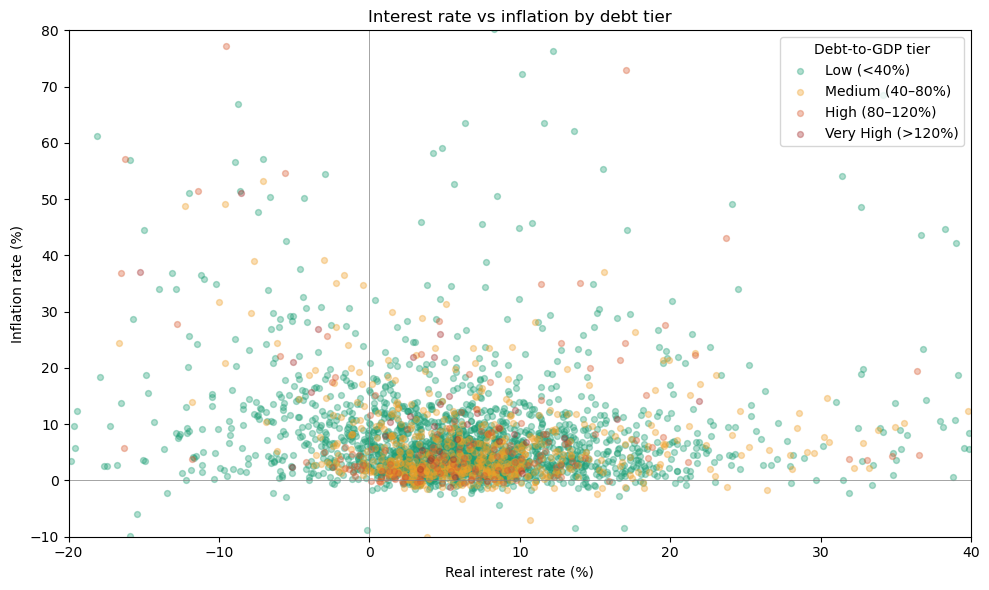

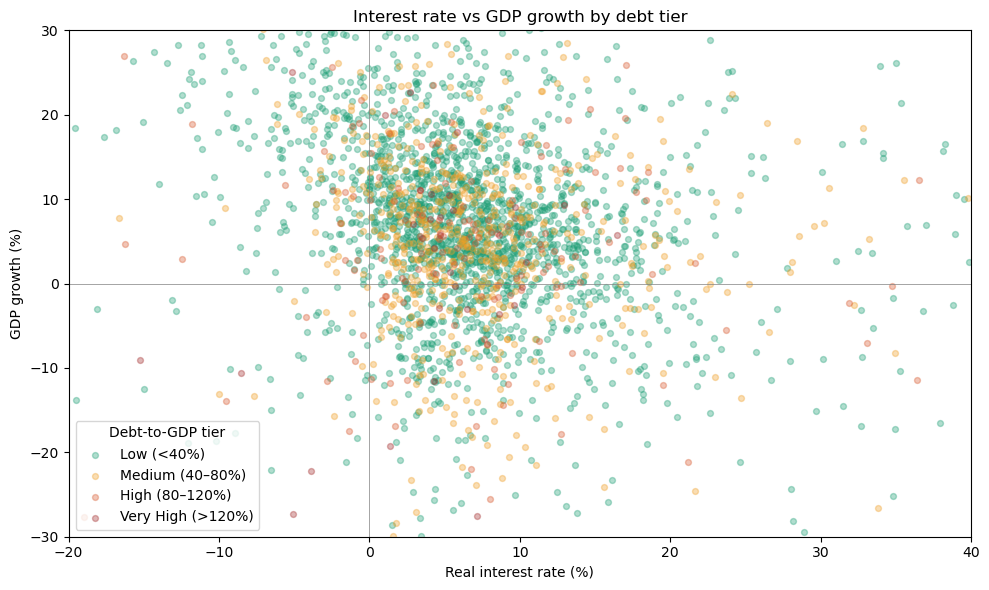

/var/folders/74/mk0c7rzs3y1dn67fmpt6dxcc0000gn/T/ipykernel_53140/19787674.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/74/mk0c7rzs3y1dn67fmpt6dxcc0000gn/T/ipykernel_53140/19787674.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tier_order, rotation=20, ha="right")


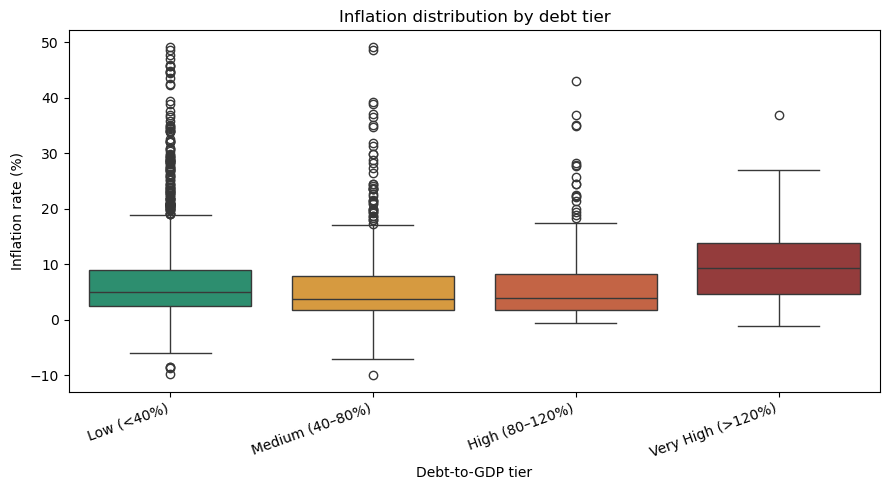

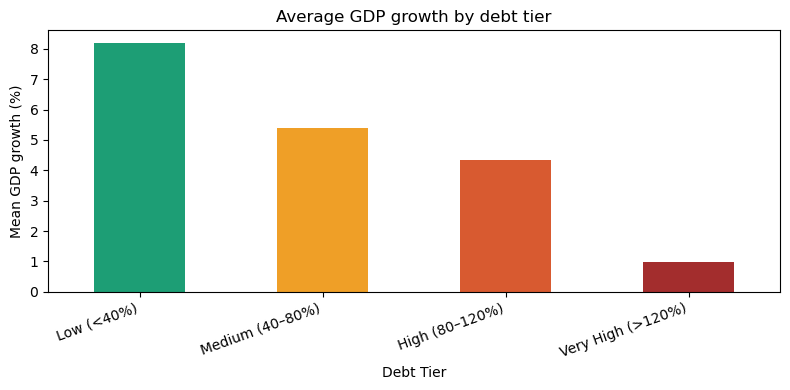

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

tier_colors = {
    "Low (<40%)":        "#1D9E75",
    "Medium (40–80%)":   "#EF9F27",
    "High (80–120%)":    "#D85A30",
    "Very High (>120%)": "#A32D2D"
}

# ── Chart 1: Interest rate vs Inflation, colored by debt tier ──
fig, ax = plt.subplots(figsize=(10, 6))
for tier, grp in df_clean.groupby("Debt Tier", observed=True):
    ax.scatter(grp["Real Interest Rate"], grp["Inflation Rate"],
              label=tier, alpha=0.35, s=18, color=tier_colors[tier])
ax.set_xlim(-20, 40); ax.set_ylim(-10, 80)
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("Real interest rate (%)")
ax.set_ylabel("Inflation rate (%)")
ax.set_title("Interest rate vs inflation by debt tier")
ax.legend(title="Debt-to-GDP tier")
plt.tight_layout(); plt.show()

# ── Chart 2: Interest rate vs GDP growth, colored by debt tier ──
df_gdp = df_clean.dropna(subset=["GDP Growth (%)"])
fig, ax = plt.subplots(figsize=(10, 6))
for tier, grp in df_gdp.groupby("Debt Tier", observed=True):
    ax.scatter(grp["Real Interest Rate"], grp["GDP Growth (%)"],
              label=tier, alpha=0.35, s=18, color=tier_colors[tier])
ax.set_xlim(-20, 40); ax.set_ylim(-30, 30)
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("Real interest rate (%)")
ax.set_ylabel("GDP growth (%)")
ax.set_title("Interest rate vs GDP growth by debt tier")
ax.legend(title="Debt-to-GDP tier")
plt.tight_layout(); plt.show()

# ── Chart 3: Inflation volatility by debt tier (box plot) ──
import seaborn as sns

tier_order = ["Low (<40%)", "Medium (40–80%)", "High (80–120%)", "Very High (>120%)"]

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df_clean[df_clean["Inflation Rate"] < 50],
    x="Debt Tier",
    y="Inflation Rate",
    order=tier_order,
    palette=tier_colors,
    ax=ax
)
ax.set_title("Inflation distribution by debt tier")
ax.set_xlabel("Debt-to-GDP tier")
ax.set_ylabel("Inflation rate (%)")
ax.set_xticklabels(tier_order, rotation=20, ha="right")
plt.tight_layout()
plt.show()

# ── Chart 4: Average GDP growth by tier — bar chart ──
avg_gdp = (df_gdp.groupby("Debt Tier", observed=True)["GDP Growth (%)"]
           .mean().reindex(tier_order))
fig, ax = plt.subplots(figsize=(8, 4))
avg_gdp.plot(kind="bar", ax=ax,
             color=[tier_colors[t] for t in tier_order],
             edgecolor="none")
ax.axhline(0, color="gray", lw=0.5)
ax.set_xticklabels(tier_order, rotation=20, ha="right")
ax.set_title("Average GDP growth by debt tier")
ax.set_ylabel("Mean GDP growth (%)")
plt.tight_layout(); plt.show()

In [35]:
summary = df_clean.groupby("Debt Tier", observed=True).agg(
    n_obs          = ("Real Interest Rate", "count"),
    avg_interest   = ("Real Interest Rate", "mean"),
    avg_inflation  = ("Inflation Rate",    "mean"),
    std_inflation  = ("Inflation Rate",    "std"),
    avg_gdp_growth = ("GDP Growth (%)",    "mean"),
    avg_mktcap     = ("Market Capitalization to GDP", "mean")
).reindex(tier_order).round(2)

print(summary)

                   n_obs  avg_interest  avg_inflation  std_inflation  \
Debt Tier                                                              
Low (<40%)          2110          6.27           9.60          35.22   
Medium (40–80%)      630          6.59          23.90         219.42   
High (80–120%)       157          6.57          58.89         596.66   
Very High (>120%)     38          2.67          16.51          23.05   

                   avg_gdp_growth  avg_mktcap  
Debt Tier                                      
Low (<40%)                   8.20       46.43  
Medium (40–80%)              5.38       73.85  
High (80–120%)               4.33       92.76  
Very High (>120%)            0.99       71.30  
